<a href="https://colab.research.google.com/github/developper669-cloud/MMIT-PPM/blob/main/notebooks/gik_icechain_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GIK-IceChain — End-to-End Walkthrough

Single notebook that exercises the pipeline **component by component**, then runs the
**full pipeline**, then reports **benchmarks**:

1. **Setup** — locate the repo, download public prerequisites, load config.
2. **C1** — IceChunk virtual store (live) or a synthetic forecast day (offline/CI).
3. **C2** — adaptive GEV exceedance probabilities.
4. **C3** — CRMA Bayesian-Network risk inference.
5. **Full pipeline** — `gik-icechain run-all` (live only; skipped offline).
6. **Benchmarks** — storage / performance vs a full Zarr copy.

It runs offline with synthetic data (CI / no credentials); set MinIO/AWS creds in
`.env` (or env vars) to exercise the live stores and the full pipeline.

## 0. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


def _bootstrap() -> Path:
    """Locate the repo root; clone it next to the cwd only if not found
    (never hardcodes a Colab /content path, so it also runs on CI runners)."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "configs" / "default.yaml").exists():
            return p
    repo = Path.cwd() / "gik-icechain"
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/hashirama21/gik-icechain.git", str(repo)], check=True)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", f"{repo}[dev]"], check=True)
    return repo


REPO = _bootstrap()
DATA = REPO / "data"
sys.path.insert(0, str(REPO / "src"))

# Idempotent: public prerequisites (admin boundaries, CMORPH RPs, ENSO/IOD, thresholds).
tools = [sys.executable, str(REPO / "scripts" / "tools.py")]
if not (DATA / "cmorph_thresholds").exists():
    subprocess.run([*tools, "download", "--component", "all"], check=True)
    subprocess.run([*tools, "download-thresholds"], check=True)

# Optional .env credentials for the live MinIO store (offline mode works without).
_env = REPO / ".env"
if _env.exists():
    for _line in _env.read_text().splitlines():
        if _line and not _line.startswith("#") and "=" in _line:
            _k, _v = _line.split("=", 1)
            os.environ.setdefault(_k.strip(), _v.strip())
os.environ.setdefault("AWS_ACCESS_KEY_ID", os.environ.get("MINIO_ACCESS_KEY", ""))
os.environ.setdefault("AWS_SECRET_ACCESS_KEY", os.environ.get("MINIO_SECRET_KEY", ""))

from gik_icechain.shared.config import load_config

cfg = load_config(REPO / "configs" / "default.yaml")
STORAGE_OPTIONS = {"endpoint_url": cfg.outputs.endpoint_url} if cfg.outputs.endpoint_url else {}
LIVE = bool(cfg.outputs.endpoint_url and os.environ.get("AWS_ACCESS_KEY_ID"))
START = date(2025, 11, 19)  # demo date for the climate-mode lookup (offline-safe)
print(f"Repo  : {REPO}")
print(f"Mode  : {'LIVE (' + cfg.outputs.endpoint_url + ')' if LIVE else 'OFFLINE (synthetic demo data)'}")


def _synthetic_day_ds():
    """Synthetic mm-scale ensemble tp for offline/CI demo (no live store)."""
    rng = np.random.default_rng(0)
    nm, ns, ny, nx = 51, 8, 30, 30
    tp = np.cumsum(rng.exponential(8.0, (nm, ns, ny, nx)), axis=1).astype("float32")
    return xr.Dataset(
        {"tp": (["member", "step", "latitude", "longitude"], tp)},
        coords={"member": np.arange(nm), "step": np.arange(0, ns * 6, 6),
                "latitude": np.linspace(23, -13, ny), "longitude": np.linspace(22, 53, nx)},
    )


Repo  : /content/gik-icechain
Mode  : OFFLINE (synthetic demo data)


## 1. Component 1 — IceChunk virtual store

C1 ingests IFS ENS GRIB2 forecasts into an IceChunk **virtual** store (chunk manifests
only, ~MB not TB). Live: open the store; offline: a synthetic mm-scale forecast day.

In [2]:
from gik_icechain.conversion.icechunk_writer import IceChainStore

day_ds = None
if LIVE:
    try:
        store = IceChainStore(
            cfg.outputs.icechunk_store_uri,
            region=cfg.outputs.icechunk_store_region,
            endpoint_url=cfg.outputs.endpoint_url,
        )
        store.create_or_open()
        report = store.validate()
        print(f"Committed days: {report['committed_days']} | range {report['date_range']}")
        session = store.readonly_session()
        latest = sorted(store.list_snapshots(), key=lambda s: s.get("date", ""))[-1]["date"]
        day_ds = xr.open_zarr(session.store, group=latest, consolidated=False)[["tp"]]
    except Exception as exc:
        print(f"Store unavailable ({type(exc).__name__}: {str(exc)[:70]}) — synthetic demo")
        day_ds = None
if day_ds is None:
    day_ds = _synthetic_day_ds()

print(f"tp shape : {day_ds['tp'].shape}  (member, step, lat, lon)")
print(f"members  : {day_ds.sizes.get('member')} | steps: {day_ds.sizes.get('step')}")


tp shape : (51, 8, 30, 30)  (member, step, lat, lon)
members  : 51 | steps: 8


## 2. Component 2 — Adaptive GEV exceedance probabilities

C2 computes rolling accumulations, selects the GEV return-period threshold for the
current season + ENSO/IOD climate mode, and turns the ensemble into exceedance
probabilities per grid cell.

In [3]:
from gik_icechain.exceedance.accumulations import compute_rolling_accumulations
from gik_icechain.exceedance.thresholds import (
    AdaptiveGEVThresholds, ClimateMode, classify_enso, classify_iod, get_season,
)
from gik_icechain.exceedance.exceedance import (
    compute_exceedance_probabilities, compute_ensemble_confidence,
)

WINDOWS_H = [24, 72, 168]
acc = compute_rolling_accumulations(day_ds[["tp"]], windows_h=WINDOWS_H)

thresholds = AdaptiveGEVThresholds.load(DATA / "cmorph_thresholds")
enso_iod = (pd.read_csv(DATA / "enso_iod_index.csv", parse_dates=["date"])
            .set_index("date").sort_index())
row    = enso_iod.loc[enso_iod.index.asof(pd.Timestamp(START))]
mode   = ClimateMode(get_season(START.month),
                     classify_enso(float(row["nino34_anom"])),
                     classify_iod(float(row["dmi"])))
print(f"Climate mode: {mode.key}")

thr24 = thresholds.get(24, 5, mode)
p   = compute_exceedance_probabilities(acc, xr.Dataset({"rp_5y": thr24}), 24, 5, "member")
conf = compute_ensemble_confidence(acc, window_h=24, member_dim="member")
print(f"Exceedance 24h/5yr — min={float(p.min()):.3f} max={float(p.max()):.3f} mean={float(p.mean()):.3f}")


2026-06-18 09:43:59 [debug    ] window_accumulation_computed   window_h=24
2026-06-18 09:43:59 [debug    ] window_accumulation_computed   window_h=72
2026-06-18 09:43:59 [debug    ] window_accumulation_computed   window_h=168
2026-06-18 09:44:04 [info     ] thresholds_loaded              directory=/content/gik-icechain/data/cmorph_thresholds n_files=252
Climate mode: OND_neutral_neutral
Exceedance 24h/5yr — min=0.000 max=1.000 mean=0.264


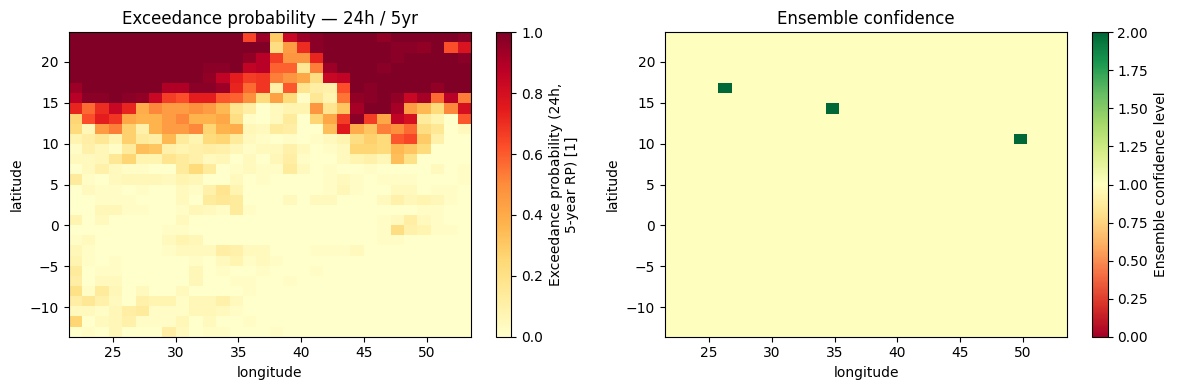

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
p.plot(ax=axes[0], cmap="YlOrRd", vmin=0, vmax=1)
axes[0].set_title("Exceedance probability — 24h / 5yr")
conf.plot(ax=axes[1], cmap="RdYlGn", vmin=0, vmax=2)
axes[1].set_title("Ensemble confidence")
fig.tight_layout(); plt.show()


## 3. Component 3 — CRMA Bayesian-Network risk inference

C3 fuses the forecast exceedance with antecedent soil moisture (API), observation
confidence and temporal/spatial persistence into a Green/Yellow/Orange/Red risk label.

In [5]:
from gik_icechain.risk.crma_model import CRMAModel, CRMAEvidence

model = CRMAModel(crma_cfg=cfg.component3.crma_model)
model.build()
print("CRMA model built — nodes:", list(model._model.nodes()))

# Per-window exceedance means drive the Forecast_Hazard node.
p72  = compute_exceedance_probabilities(
    compute_rolling_accumulations(day_ds[["tp"]], windows_h=[72]),
    xr.Dataset({"rp_5y": thresholds.get(72, 5, mode)}), 72, 5, "member")
p168 = compute_exceedance_probabilities(
    compute_rolling_accumulations(day_ds[["tp"]], windows_h=[168]),
    xr.Dataset({"rp_5y": thresholds.get(168, 5, mode)}), 168, 5, "member")

# A few representative antecedent-soil scenarios over the same forecast field.
scenarios = {
    "dry soil":        dict(api_mm=10.0,  sat_consecutive_days=0),
    "normal soil":     dict(api_mm=45.0,  sat_consecutive_days=0),
    "saturated soil":  dict(api_mm=120.0, sat_consecutive_days=8),
}
rows = []
for name, extra in scenarios.items():
    ev = CRMAEvidence(
        exceedance_prob_24h=float(p.mean()),
        exceedance_prob_72h=float(p72.mean()),
        exceedance_prob_7d=float(p168.mean()),
        gpm_obs_24h=0.0,
        spatial_coverage_fraction=float((p > 0.15).mean()),
        consecutive_signal_days=1,
        **extra,
    )
    res = model.infer(ev)
    rows.append({"scenario": name, "risk": res["risk_label"],
                 "p_green": res["p_green"], "p_yellow": res["p_yellow"],
                 "p_orange": res["p_orange"], "p_red": res["p_red"]})
risk_df = pd.DataFrame(rows)
print(risk_df.to_string(index=False))


/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


2026-06-18 09:44:26 [info     ] crma_model_built               cluster=equatorial_east nodes=9
CRMA model built — nodes: ['Forecast_Hazard', 'Compound_Risk', 'Obs_Antecedent', 'Temporal_Persist', 'Spatial_Coverage', 'Data_Confidence', 'API_State', 'Soil_Memory', 'Risk_State']
2026-06-18 09:44:26 [debug    ] window_accumulation_computed   window_h=72
2026-06-18 09:44:26 [debug    ] window_accumulation_computed   window_h=168
      scenario   risk  p_green  p_yellow  p_orange  p_red
      dry soil  Green   0.5060    0.3120    0.1250 0.0570
   normal soil Yellow   0.2065    0.3180    0.2965 0.1790
saturated soil Orange   0.1370    0.2648    0.3106 0.2876


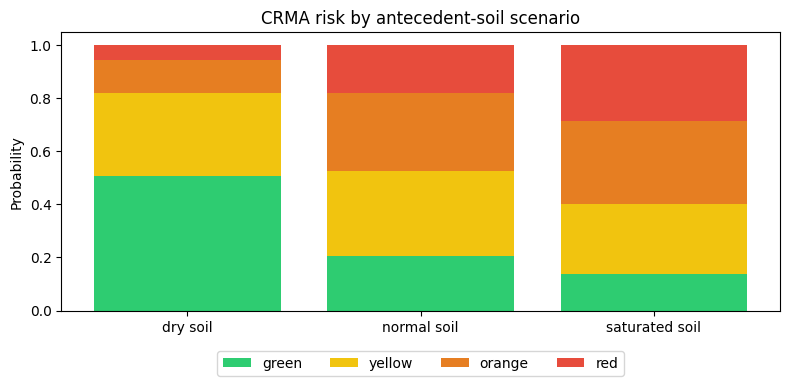

In [6]:
colors = {"Green": "#2ecc71", "Yellow": "#f1c40f", "Orange": "#e67e22", "Red": "#e74c3c"}
fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(risk_df))
for lab in ["p_green", "p_yellow", "p_orange", "p_red"]:
    ax.bar(risk_df["scenario"], risk_df[lab], bottom=bottom,
           color=colors[lab.split("_")[1].capitalize()], label=lab.split("_")[1])
    bottom += risk_df[lab].values
ax.set_ylabel("Probability"); ax.set_title("CRMA risk by antecedent-soil scenario")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12)); fig.tight_layout(); plt.show()


## 4. Full pipeline — `gik-icechain run-all`

Runs C1 → C2 → C3 over a date range and writes per-day `*_risk_scores.json`. Requires
the live stores + ECMWF S3 access, so it is **skipped offline** (the cells above already
exercised each component on synthetic data).

In [7]:
if LIVE:
    END = (date.today() - timedelta(days=2))
    RUN_START = (date.today() - timedelta(days=3))
    OUT = REPO / "results" / "nb_e2e"
    cmd = [sys.executable, "-m", "gik_icechain", "run-all",
           "--start", RUN_START.isoformat(), "--end", END.isoformat(),
           "--config", str(REPO / "configs" / "default.yaml"), "--output", str(OUT)]
    print("Running:", " ".join(cmd))
    rc = subprocess.run(cmd, env={**os.environ, "ECCODES_PYTHON_USE_FINDLIBS": "1"}).returncode
    print("Pipeline finished" if rc == 0 else f"Pipeline failed (exit {rc})")
else:
    print("Offline: skipping run-all (needs live stores + ECMWF S3).")
    print("Live equivalent:")
    print("  gik-icechain run-all --start <D> --end <D> --config configs/default.yaml --output results/")


Offline: skipping run-all (needs live stores + ECMWF S3).
Live equivalent:
  gik-icechain run-all --start <D> --end <D> --config configs/default.yaml --output results/


In [8]:
# Verify + summarise any risk_scores produced (live run-all, or a prior local run).
import glob, json

risk_dirs = [REPO / "results" / "nb_e2e" / "admin1_risk", REPO / "results" / "admin1_risk"]
files = next((sorted(glob.glob(str(d / "*_risk_scores.json"))) for d in risk_dirs
             if list(d.glob("*_risk_scores.json"))), [])
if not files:
    print("No risk_scores found yet — run the full pipeline (live) to populate results/.")
else:
    print(f"{'Date':<12} {'Units':>6}  Risk distribution")
    for f in files[-7:]:
        doc = json.load(open(f))
        c: dict[str, int] = {}
        for u in doc["units"].values():
            c[u["risk_label"]] = c.get(u["risk_label"], 0) + 1
        print(f"{doc['date']:<12} {len(doc['units']):>6}  " +
              ", ".join(f"{k}: {v}" for k, v in sorted(c.items())))


No risk_scores found yet — run the full pipeline (live) to populate results/.


## 5. Benchmarks — storage & performance

GIK+IceChunk stores only chunk **manifests** (pointers into the public ECMWF S3 GRIB2),
so the store is ~MB while a full Zarr copy is ~hundreds of TB. Set `RUN_LIVE = True` to
measure against the live store; otherwise reference numbers from production runs are used.

In [9]:
RUN_LIVE = False
RESULTS_DIR = REPO / "results" / "benchmarks"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
csv_files = sorted(RESULTS_DIR.glob("benchmark_east_africa_*.csv"))

if RUN_LIVE and LIVE:
    from gik_icechain.conversion.benchmark import run_benchmark
    run_benchmark(gik_store_uri=cfg.outputs.icechunk_store_uri, domain="east_africa",
                  n_days=7, n_workers=4, output_dir=str(RESULTS_DIR))
    csv_files = sorted(RESULTS_DIR.glob("benchmark_east_africa_*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[-1]); print(f"Loaded {csv_files[-1].name}")
else:
    df = pd.DataFrame([
        {"approach": "GIK+IceChunk",  "n_days": 7, "store_size_gb": 18.5,
         "time_to_first_byte_s": 1.8, "full_scan_elapsed_s": 141.0, "n_workers": 32},
        {"approach": "dynamical.org", "n_days": 7, "store_size_gb": 242_000.0,
         "time_to_first_byte_s": 0.9, "full_scan_elapsed_s": 480.0, "n_workers": 32},
    ])
    print("Using reference numbers from production runs.")

summary = df[["approach", "store_size_gb", "time_to_first_byte_s", "full_scan_elapsed_s"]].copy()
summary["store"] = summary["store_size_gb"].apply(lambda x: f"{x:.1f} GB" if x < 1000 else f"{x/1000:.0f} TB")
print(summary[["approach", "store", "time_to_first_byte_s", "full_scan_elapsed_s"]].to_string(index=False))
gik = float(df.loc[df["approach"] == "GIK+IceChunk", "store_size_gb"].iloc[0])
print(f"\nCompression vs full Zarr copy: {242_000.0 / gik:,.0f}x  ({gik:.1f} GB vs 242 TB)")


Using reference numbers from production runs.
     approach   store  time_to_first_byte_s  full_scan_elapsed_s
 GIK+IceChunk 18.5 GB                   1.8                141.0
dynamical.org  242 TB                   0.9                480.0

Compression vs full Zarr copy: 13,081x  (18.5 GB vs 242 TB)


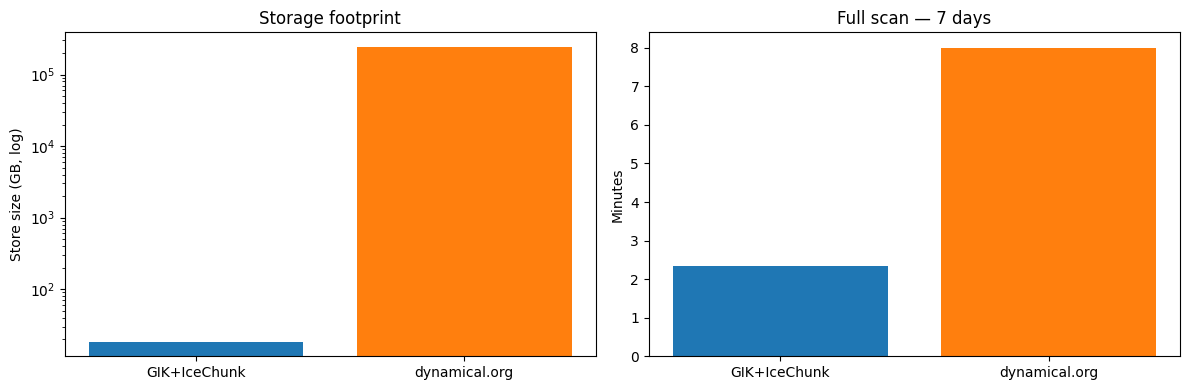

Walkthrough complete: C1 -> C2 -> C3 -> full pipeline -> benchmarks.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
a = df["approach"].tolist(); cols = ["#1f77b4", "#ff7f0e"]
axes[0].bar(a, df["store_size_gb"], color=cols[:len(a)]); axes[0].set_yscale("log")
axes[0].set_ylabel("Store size (GB, log)"); axes[0].set_title("Storage footprint")
axes[1].bar(a, df["full_scan_elapsed_s"] / 60, color=cols[:len(a)])
axes[1].set_ylabel("Minutes"); axes[1].set_title(f"Full scan — {int(df['n_days'].iloc[0])} days")
fig.tight_layout(); plt.show()
print("Walkthrough complete: C1 -> C2 -> C3 -> full pipeline -> benchmarks.")
